In [25]:
#!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

In [26]:
import pandas as pd
import numpy as np

In [27]:
"""In this dataset our desired target for classification task will be converted variable - has the client signed up to the platform or not.
Data preparation
Check if the missing values are presented in the features.
If there are missing values:
For categorical features, replace them with 'NA'
For numerical features, replace them with 0.0
"""

df = pd.read_csv('/home/ron/projects/ml-zoomcamp-homework/3.homework/course_lead_scoring.csv')
print(df.head())

missing_before = df.isna().sum()
print('\nMissing values before filling:')
print(missing_before[missing_before > 0])

for column in df.columns:
    if df[column].isna().any():
        if pd.api.types.is_numeric_dtype(df[column]):
            df[column] = df[column].fillna(0.0)
        else:
            df[column] = df[column].fillna('NA')

print('\nMissing values after filling:')
print(df.isna().sum())

    lead_source    industry  number_of_courses_viewed  annual_income  \
0      paid_ads         NaN                         1        79450.0   
1  social_media      retail                         1        46992.0   
2        events  healthcare                         5        78796.0   
3      paid_ads      retail                         2        83843.0   
4      referral   education                         3        85012.0   

  employment_status       location  interaction_count  lead_score  converted  
0        unemployed  south_america                  4        0.94          1  
1          employed  south_america                  1        0.80          0  
2        unemployed      australia                  3        0.69          1  
3               NaN      australia                  1        0.87          0  
4     self_employed         europe                  3        0.62          1  

Missing values before filling:
lead_source          128
industry             134
annual_inco

In [28]:
"""Question 1
What is the most frequent observation (mode) for the column industry?
NA
technology
healthcare
retail"""

df['industry'].mode()

0    retail
Name: industry, dtype: str

Correlation matrix:
                          number_of_courses_viewed  annual_income  \
number_of_courses_viewed                  1.000000       0.009770   
annual_income                             0.009770       1.000000   
interaction_count                        -0.023565       0.027036   
lead_score                               -0.004879       0.015610   

                          interaction_count  lead_score  
number_of_courses_viewed          -0.023565   -0.004879  
annual_income                      0.027036    0.015610  
interaction_count                  1.000000    0.009888  
lead_score                         0.009888    1.000000  


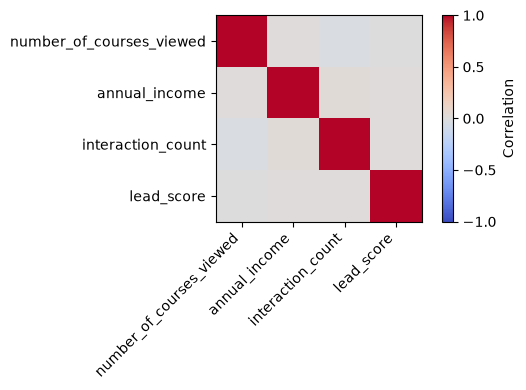


Candidate pair correlations:
interaction_count and lead_score: 0.009888182496913131
number_of_courses_viewed and lead_score: -0.004878998354681276
number_of_courses_viewed and interaction_count: -0.023565222882888037
annual_income and interaction_count: 0.02703647240481443
Biggest correlation: annual_income and interaction_count

Split sizes:
train: 876, validation: 293, test: 293
Target column in feature dataframes: False


In [29]:
"""Question 2
Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

interaction_count and lead_score
number_of_courses_viewed and lead_score
number_of_courses_viewed and interaction_count
annual_income and interaction_count
Only consider the pairs above when answering this question.

Split the data
Split your data in train/val/test sets with 60%/20%/20% distribution.
Use Scikit-Learn for that (the train_test_split function) and set the seed to 42.
Make sure that the target value converted is not in your dataframe.
"""

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Keep the target separate from the feature dataframe.
y = df['converted'].copy()
X = df.drop(columns=['converted']).copy()

numeric_features = X.select_dtypes(include='number').columns
correlation_matrix = X[numeric_features].corr()
print('Correlation matrix:')
print(correlation_matrix)

plt.figure(figsize=(6, 4))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(numeric_features)), numeric_features, rotation=45, ha='right')
plt.yticks(range(len(numeric_features)), numeric_features)
plt.colorbar(label='Correlation')
plt.tight_layout()
plt.show()

candidate_pairs = [
    ('interaction_count', 'lead_score'),
    ('number_of_courses_viewed', 'lead_score'),
    ('number_of_courses_viewed', 'interaction_count'),
    ('annual_income', 'interaction_count'),
]
pair_correlations = {
    pair: correlation_matrix.loc[pair[0], pair[1]]
    for pair in candidate_pairs
}
print('\nCandidate pair correlations:')
for pair, correlation in pair_correlations.items():
    print(f'{pair[0]} and {pair[1]}: {correlation}')

best_pair = max(candidate_pairs, key=lambda pair: abs(pair_correlations[pair]))
print(f'Biggest correlation: {best_pair[0]} and {best_pair[1]}')

# Split 20% for test, then 25% of the remaining 80% for validation.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print('\nSplit sizes:')
print(f'train: {len(X_train)}, validation: {len(X_val)}, test: {len(X_test)}')
print('Target column in feature dataframes:', any(
    'converted' in split.columns for split in [X_train, X_val, X_test]
))

In [30]:
"""Question 3
Calculate the mutual information score between converted and other categorical variables in the dataset. Use the training set only.
Round the scores to 2 decimals using round(score, 2).
Which of these variables has the biggest mutual information score?

industry
location
lead_source
employment_status
"""

from sklearn.metrics import mutual_info_score

categorical_features = ['industry', 'location', 'lead_source', 'employment_status']
mi_scores = {
    feature: round(mutual_info_score(X_train[feature], y_train), 2)
    for feature in categorical_features
}

print('Mutual information scores:')
for feature, score in mi_scores.items():
    print(f'{feature}: {score}')

best_feature = max(mi_scores, key=mi_scores.get)
print(f'Highest score: {best_feature} ({mi_scores[best_feature]})')

Mutual information scores:
industry: 0.01
location: 0.0
lead_source: 0.04
employment_status: 0.01
Highest score: lead_source (0.04)


In [31]:
"""Question 4
Now let's train a logistic regression.
Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
Fit the model on the training dataset.
To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
Calculate the accuracy on the validation dataset and round it to 2 decimal digits.
What accuracy did you get?"""

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_val_encoded = preprocessor.transform(X_val)

model = LogisticRegression(
    solver='liblinear', C=1.0, max_iter=1000, random_state=42
)
model.fit(X_train_encoded, y_train)
val_predictions = model.predict(X_val_encoded)
accuracy = accuracy_score(y_val, val_predictions)
print('Validation accuracy:', round(accuracy, 2))

Validation accuracy: 0.7


In [32]:
"""Question 5
Let's find the least useful feature using the feature elimination technique.
Train a model using the same features and parameters as in Q4 (without rounding).
Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
For each feature, calculate the difference between the original accuracy and the accuracy without the feature.
Which of following feature has the smallest difference?

'industry'
'employment_status'
'lead_score'
"""

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


def get_validation_accuracy(feature_names):
    train_features = X_train[feature_names]
    val_features = X_val[feature_names]
    categorical_columns = train_features.select_dtypes(exclude='number').columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns)
        ],
        remainder='passthrough'
    )
    train_encoded = preprocessor.fit_transform(train_features)
    val_encoded = preprocessor.transform(val_features)

    model = LogisticRegression(
        solver='liblinear', C=1.0, max_iter=1000, random_state=42
    )
    model.fit(train_encoded, y_train)
    predictions = model.predict(val_encoded)
    return accuracy_score(y_val, predictions)


all_features = X_train.columns.tolist()
original_accuracy = get_validation_accuracy(all_features)
features_to_remove = ['industry', 'employment_status', 'lead_score']
accuracies_without_feature = {}
accuracy_differences = {}

for feature in features_to_remove:
    remaining_features = [name for name in all_features if name != feature]
    accuracy_without_feature = get_validation_accuracy(remaining_features)
    accuracies_without_feature[feature] = accuracy_without_feature
    accuracy_differences[feature] = original_accuracy - accuracy_without_feature

print(f'Original accuracy: {original_accuracy}')
for feature in features_to_remove:
    print(
        f"Without {feature}: accuracy={accuracies_without_feature[feature]}, "
        f"difference={accuracy_differences[feature]}"
    )

least_useful_feature = min(accuracy_differences, key=accuracy_differences.get)
print(f'Smallest difference: {least_useful_feature} ({accuracy_differences[least_useful_feature]})')

Original accuracy: 0.6996587030716723
Without industry: accuracy=0.6996587030716723, difference=0.0
Without employment_status: accuracy=0.6962457337883959, difference=0.0034129692832763903
Without lead_score: accuracy=0.7064846416382252, difference=-0.0068259385665528916
Smallest difference: lead_score (-0.0068259385665528916)


In [33]:
"""Question 6
Now let's train a regularized logistic regression.
Let's try the following values of the parameter C: [0.01, 0.1, 1, 10, 100].
Train models using all the features as in Q4.
Calculate the accuracy on the validation dataset and round it to 3 decimal digits.
Which of these C leads to the best accuracy on the validation set?"""

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()
preprocessor_q6 = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)
X_train_q6 = preprocessor_q6.fit_transform(X_train)
X_val_q6 = preprocessor_q6.transform(X_val)

C_values = [0.01, 0.1, 1, 10, 100]
accuracy_by_C = {}

for C in C_values:
    model_q6 = LogisticRegression(
        solver='liblinear', C=C, max_iter=1000, random_state=42
    )
    model_q6.fit(X_train_q6, y_train)
    predictions_q6 = model_q6.predict(X_val_q6)
    accuracy_by_C[C] = accuracy_score(y_val, predictions_q6)
    print(f'C={C}: accuracy={round(accuracy_by_C[C], 3)}')

best_C = max(C_values, key=lambda value: accuracy_by_C[value])
print(f'Best C: {best_C} (accuracy={round(accuracy_by_C[best_C], 3)})')

C=0.01: accuracy=0.7
C=0.1: accuracy=0.7
C=1: accuracy=0.7
C=10: accuracy=0.7
C=100: accuracy=0.7
Best C: 0.01 (accuracy=0.7)


# Notebook Guide

This notebook explores a course lead-scoring dataset and builds a binary classification model. The target, `converted`, indicates whether a lead signed up: `1` means converted and `0` means not converted.

## Cell-by-cell walkthrough

### Cell 1: Download the dataset
The `wget` command can download the CSV from the course dataset URL. It is commented out, so it will not run when the cell executes. The next data-preparation cell reads the existing local CSV file.

### Cell 2: Import libraries
Imports pandas for working with tabular data and NumPy for numerical operations used later in the notebook.

### Cell 3: Load and prepare the data
Reads the CSV into `df`, displays the first rows, and counts missing values by column. It fills missing numerical values with `0.0` and missing categorical values with the string `'NA'`, then prints the missing-value counts again to verify the fill. The target column has no missing values in this dataset.

### Cell 4: Question 1, industry mode
Uses `df['industry'].mode()` to find the most frequent value in the `industry` column. Pandas returns a Series so it can represent multiple modes in the event of a tie.

### Cell 5: Question 2 and data split
Separates the target into `y` and creates `X` by dropping `converted`, keeping the target out of the feature dataframe. It calculates correlations among numerical features, displays the matrix and a heatmap, and compares only the four candidate pairs listed in the question. Correlations are compared by absolute magnitude; the largest listed pair is `annual_income` and `interaction_count` (about `0.027`).

The same cell creates train, validation, and test sets using `train_test_split` with seed `42`. It first holds out 20% for testing, then assigns 25% of the remaining data to validation, giving the requested 60/20/20 proportions. The target labels are stored separately in `y_train`, `y_val`, and `y_test`.

### Cell 6: Question 3, mutual information
Calculates mutual information between `converted` and each of the four categorical features using only `X_train` and `y_train`. Scores are rounded to two decimal places. Among the listed features, `lead_source` has the highest score (`0.04`).

### Cell 7: Question 4, logistic regression
Identifies categorical columns from the training features and one-hot encodes them. The encoder is fit on training data and then applied to validation data, avoiding learning categories from the validation set. A logistic regression model with the specified `liblinear` solver and parameters is fit on the encoded training data. Its validation accuracy is about `0.70` when rounded to two decimals.

### Cell 8: Question 5, feature elimination
Defines a helper that trains and evaluates the same logistic regression setup using a chosen feature subset. It records the baseline accuracy, then retrains after removing `industry`, `employment_status`, or `lead_score`. Each difference is computed as baseline accuracy minus accuracy without that feature. The smallest signed difference is for `lead_score` (about `-0.00683`); removing it slightly improves validation accuracy.

### Cell 9: Question 6, regularization strength
One-hot encodes all features using training data, then fits a logistic regression model for each requested `C` value: `0.01`, `0.1`, `1`, `10`, and `100`. It evaluates each model on the validation set and prints accuracy to three decimal places. The highest accuracy is selected using the unrounded scores; the best `C` printed by this run is `0.01` (the scores display as `0.700` when rounded).

## Workflow summary
The target is kept separate from features; preprocessing is fitted using training data and reused for validation. Questions 4–6 use validation accuracy to compare the baseline model, feature subsets, and regularization strengths. The test set is created in Question 2 but is not used in these validation comparisons.